<a href="https://colab.research.google.com/github/Joelmagranes/Final-DataScience-3/blob/main/EntregaFinal_DataScience3_JoelMagranes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto Final – Ciencia de Datos**
## **Análisis de Sentimientos en Reseñas de Películas mediante NLP**


## **Presentación del proyecto**

Este proyecto tiene como objetivo desarrollar un modelo de análisis de sentimientos
capaz de clasificar reseñas de películas como positivas o negativas, utilizando técnicas
de Procesamiento de Lenguaje Natural (NLP) y algoritmos de clasificación supervisada. Se
trabajó con un conjunto de 46.173 reseñas de películas en inglés, cada una acompañada de
una calificación numérica (Rating) de 1 a 10 otorgada por el usuario. A partir de esa
calificación se derivó la variable objetivo de sentimiento (positivo/negativo), siguiendo
el criterio estándar utilizado en datasets de referencia como IMDB. El flujo de trabajo
incluyó etapas de preprocesamiento textual —normalización, tokenización, eliminación de
stopwords y lematización—, representación numérica mediante CountVectorizer y TF-IDF, y
entrenamiento de distintos modelos de clasificación clásicos (Naive Bayes, Regresión
Logística, Random Forest y SVM), comparando su desempeño.
Finalmente, se incorporó una red neuronal densa simple (MLP) para evaluar si un enfoque de Deep Learning podía superar al mejor modelo clásico.

## **Motivación**

La gran cantidad de opiniones publicadas diariamente en plataformas digitales hace
necesario el uso de herramientas automáticas capaces de interpretar el sentimiento
expresado por los usuarios. En el ámbito cinematográfico, las reseñas contienen
información valiosa sobre la percepción del público respecto a una película, y pueden
utilizarse para evaluar su recepción de forma agregada y escalable. La motivación
principal de este trabajo es aplicar conocimientos de NLP y aprendizaje automático para
construir un sistema capaz de identificar automáticamente si una reseña expresa una
opinión positiva o negativa.



## **Contexto Comercial**

Las empresas de entretenimiento, plataformas de streaming y sitios de reseñas reciben
grandes volúmenes de comentarios de usuarios todos los días. Analizar manualmente esas
opiniones resulta costoso, lento y poco escalable. Un sistema automático de análisis de
sentimientos puede ayudar a detectar rápidamente la percepción general del público sobre
una película, identificar contenidos mejor o peor valorados, y apoyar decisiones
relacionadas con recomendaciones de contenido, campañas de marketing y mejora de la
experiencia del usuario.

## **Contexto Analítico**

Desde el punto de vista analítico, el problema se plantea como una tarea de
clasificación supervisada binaria. Las reseñas textuales constituyen la variable de
entrada, y el sentimiento (positivo o negativo), derivado del Rating original, representa
la variable objetivo. El desafío consiste en transformar texto no estructurado en una
representación numérica adecuada (vectorización) y entrenar modelos capaces de
generalizar correctamente sobre reseñas no vistas durante el entrenamiento. Se comparan
distintos algoritmos de clasificación y dos técnicas de vectorización, con el fin de
identificar la combinación más efectiva antes de avanzar hacia un enfoque de Deep
Learning en una etapa posterior.

## **Preguntas / Hipótesis a resolver**

*   ¿Es posible clasificar automáticamente reseñas de películas en positivas o
negativas utilizando técnicas básicas de NLP?

*   ¿Cuál de las representaciones vectoriales (CountVectorizer o TF-IDF) conserva
suficiente información para lograr una clasificación más efectiva?

*   ¿Qué algoritmo de clasificación clásico (Naive Bayes, Regresión Logística, Random
Forest o SVM) obtiene el mejor desempeño para esta tarea?

*   ¿Un modelo de clasificación clásico entrenado sobre texto vectorizado alcanza un
desempeño adecuado, o se justifica avanzar hacia una red neuronal?

## **Objetivos**

Desarrollar y evaluar un modelo de análisis de sentimientos para clasificar reseñas de
películas como positivas o negativas, mediante técnicas de Procesamiento de Lenguaje
Natural y algoritmos de clasificación supervisada.

*   Cargar y explorar el conjunto de datos de reseñas de películas.
*   Derivar la variable objetivo de sentimiento a partir del Rating original.
*   Aplicar tareas de preprocesamiento de texto: limpieza, tokenización, eliminación de stopwords y lematización
*   Convertir las reseñas en vectores numéricos mediante CountVectorizer y TF-IDF.
*   Entrenar y comparar distintos modelos de clasificación supervisada.
*   Evaluar los modelos mediante accuracy, reporte de clasificación y matrices de confusion
*   Interpretar los resultados obtenidos y discutir posibles mejoras, incluyendo la incorporacion de red neuronal

## 1. Importar librerías

In [1]:
!pip install -q wordcloud

In [2]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

## 2. Cargar el dataset

In [3]:
url = "https://docs.google.com/spreadsheets/d/12x18yo5geQ_tOCvaPeshQ970SXXmw_NC/export?format=csv"

In [4]:
df = pd.read_csv(url)
print(df.shape)
df.head()

(46173, 3)


,Ratings,Reviews,movie_name
0,3,"It had some laughs, but overall the motivation...",Waiting to Exhale
1,4,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale
2,4,"Angela Basset was good as expected, but Whitne...",Waiting to Exhale
3,5,"The movie is okay, mediocre might even be the ...",Waiting to Exhale
4,5,I got an opportunity to see Waiting To Exhale ...,Waiting to Exhale


In [5]:
df.info()
print()
print("Nulos por columna:")
print(df.isna().sum())
print()
print("Duplicados:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46173 entries, 0 to 46172
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Ratings     46173 non-null  int64 
 1   Reviews     46173 non-null  object
 2   movie_name  46173 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB

Nulos por columna:
Ratings       0
Reviews       0
movie_name    0
dtype: int64

Duplicados: 26857


In [6]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape luego de eliminar duplicados:", df.shape)

Shape luego de eliminar duplicados: (19316, 3)


Luego de la carga del dataset se procedió a revisar valores nulos (no se encontraron) y se eliminaron los registros duplicados, que representaban casi un 58% del dataset original (26.857 de 46.173 filas). Al quedar con 19.316 registros únicos, aún contamos con información suficiente para cumplir los objetivos del análisis.

## 3. Definir la variable objetivo (Sentiment)

El dataset no trae una etiqueta de sentimiento lista, así que la derivamos de `Ratings`
con el criterio estándar usado en datasets IMDB:

- **Rating ≥ 7 → positive**
- **Rating ≤ 4 → negative**
- **Rating 5-6 → zona ambigua/neutral → se descarta** (para no confundir al clasificador
  con reseñas que no son claramente positivas ni negativas)


In [36]:
def rating_to_sentiment(r):
    if r >= 7:
        return 'positive'
    elif r <= 4:
        return 'negative'
    else:
        return 'neutral'

df['Sentiment'] = df['Ratings'].apply(rating_to_sentiment)

print(df['Sentiment'].value_counts())

# Nos quedamos solo con positive/negative
df = df[df['Sentiment'] != 'neutral'].reset_index(drop=True)
print()
print("Shape final (sin neutrales):", df.shape)

Sentiment
positive    9256
negative    6369
Name: count, dtype: int64

Shape final (sin neutrales): (15625, 7)


## 4. Análisis exploratorio (EDA)

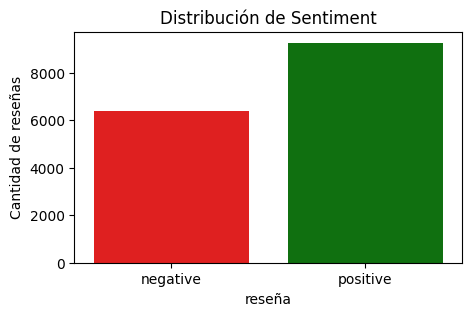

In [8]:
# Distribución de clases
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='Sentiment', hue='Sentiment',
              palette={'positive': 'green', 'negative': 'red'}, legend=False)
plt.title('Distribución de Sentiment')
plt.xlabel('reseña')
plt.ylabel('Cantidad de reseñas')
plt.show()

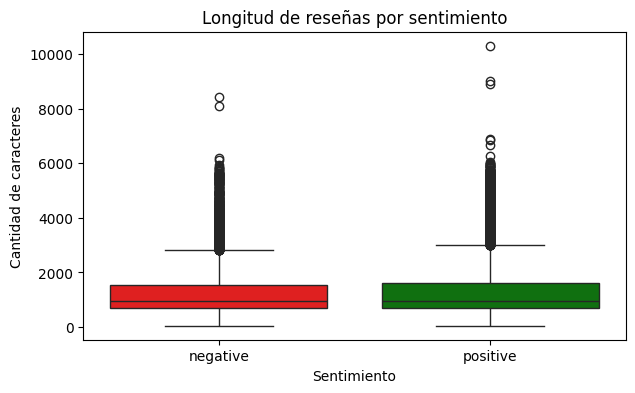

In [9]:
# Longitud de las reseñas
df['length'] = df['Reviews'].astype(str).apply(len)

plt.figure(figsize=(7, 4))
sns.boxplot(x='Sentiment', y='length', data=df, hue='Sentiment',
            palette={'positive': 'green', 'negative': 'red'}, legend=False)
plt.title('Longitud de reseñas por sentimiento')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de caracteres')
plt.show()

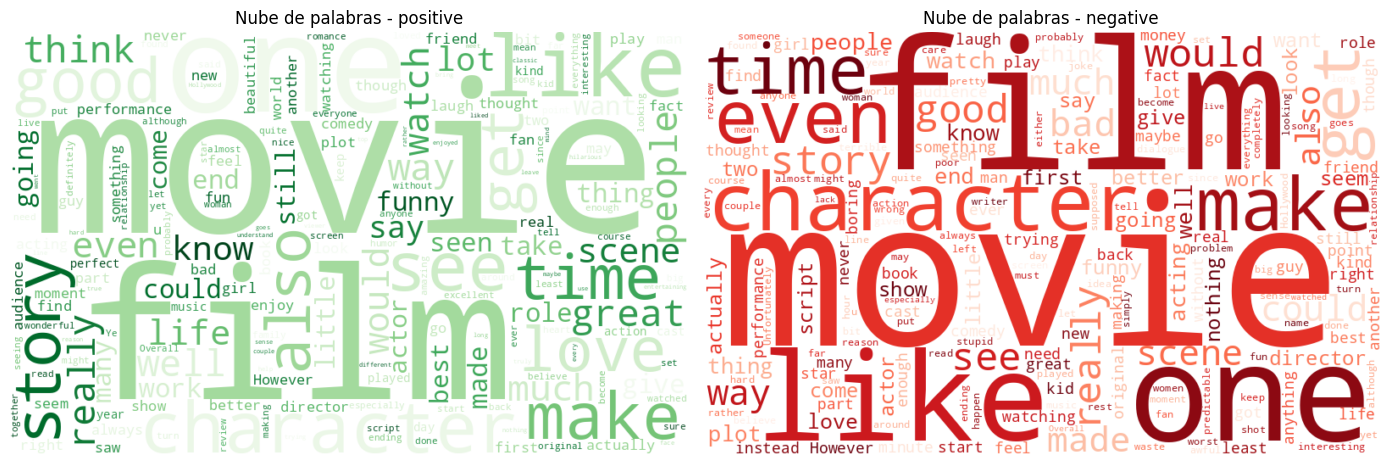

In [10]:
# WordClouds por sentimiento
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sentiment, color in zip(axes, ['positive', 'negative'], ['Greens', 'Reds']):
    text = ' '.join(df[df['Sentiment'] == sentiment]['Reviews'].astype(str))
    wc = WordCloud(width=800, height=500, background_color='white',
                   colormap=color, stopwords=set(stopwords.words('english'))).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Nube de palabras - {sentiment}')
    ax.axis('off')

plt.tight_layout()
plt.show()

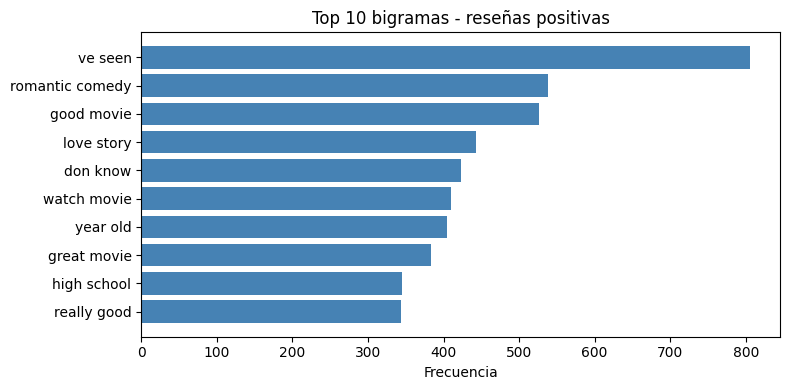

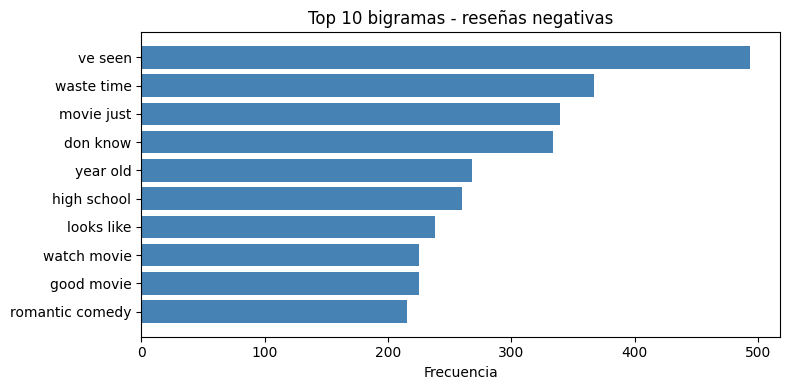

In [11]:
# Top bigramas por sentimiento
def plot_top_ngrams(comments, ngram_range=(2,2), top_n=10, title=''):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=2000)
    X = vectorizer.fit_transform(comments)
    suma_ngrams = X.sum(axis=0)
    freq = [(word, suma_ngrams[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    freq = sorted(freq, key=lambda x: x[1], reverse=True)[:top_n]
    words, counts = zip(*freq)

    plt.figure(figsize=(8, 4))
    plt.barh(words, counts, color='steelblue')
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel('Frecuencia')
    plt.tight_layout()
    plt.show()

plot_top_ngrams(df[df['Sentiment']=='positive']['Reviews'].astype(str),
                 title='Top 10 bigramas - reseñas positivas')
plot_top_ngrams(df[df['Sentiment']=='negative']['Reviews'].astype(str),
                 title='Top 10 bigramas - reseñas negativas')

## 5. Preprocesamiento de texto

Aplicamos las tareas de preprocesamiento sobre la columna Reviews (limpieza y normalización, tokenización, eliminación de stopwords y lematización). Durante la exploración observamos que ciertas palabras propias del dominio cinematográfico aparecían tanto en reseñas positivas como negativas y no aportaban información útil para el análisis de sentimiento. Por este motivo incorporamos una lista de stopwords personalizadas para eliminar términos como film, movie, character, entre otros.

In [12]:
stop_words = set(stopwords.words('english'))
stop_words.update([
    'film','movie','character','story','time','make','one','people','scene',
    'plot','show','see','watch','really','way','old','like','even','school','made','seen'
])

lemmatizer = WordNetLemmatizer()

def limpiar_texto(texto):
    texto = str(texto).lower()                          # minúsculas
    texto = re.sub(r'<.*?>', ' ', texto)                 # por si quedara HTML
    texto = re.sub(r'[^a-z\s]', ' ', texto)              # solo letras
    texto = re.sub(r'\s+', ' ', texto).strip()           # espacios múltiples

    tokens = word_tokenize(texto)                       # tokenización
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]  # stopwords
    tokens = [lemmatizer.lemmatize(w) for w in tokens]   # lematización

    return ' '.join(tokens)

df['Reviews_clean'] = df['Reviews'].apply(limpiar_texto)


for i in [0, 1]:
    print(f"--- Reseña {i} ({df['Sentiment'].iloc[i]}) ---")
    print("ORIGINAL :", df['Reviews'].iloc[i][:200])
    print("PROCESADO:", df['Reviews_clean'].iloc[i][:200])
    print()

--- Reseña 0 (negative) ---
ORIGINAL : It had some laughs, but overall the motivation of the characters was incomprehensible. Why should they be mad at men for cheating when they sleep with all sorts of married men themselves? Very hypocri
PROCESADO: laugh overall motivation character incomprehensible mad men cheating sleep sort married men hypocritical life messed messed stupid choice empathy woman

--- Reseña 1 (negative) ---
ORIGINAL : WAITING TO EXHALE Waiting, and waiting, and waiting, and waiting... you get the point. "Waiting To Exhale", Forrest Whitaker's take on Terry McMillan's popular book, had a rather popular following upo
PROCESADO: waiting exhale waiting waiting waiting waiting get point waiting exhale forrest whitaker take terry mcmillan popular book rather popular following upon release packaged brilliantly crossing popular mu



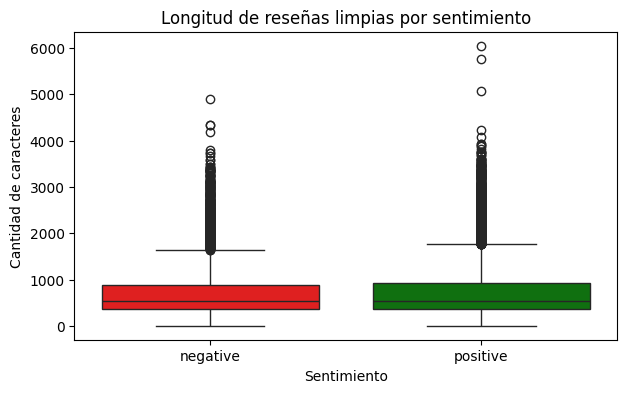

In [13]:
df['length_clean'] = df['Reviews_clean'].astype(str).apply(len)

plt.figure(figsize=(7, 4))
sns.boxplot(x='Sentiment', y='length_clean', data=df, hue='Sentiment',
            palette={'positive': 'green', 'negative': 'red'}, legend=False)
plt.title('Longitud de reseñas limpias por sentimiento')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de caracteres')
plt.show()


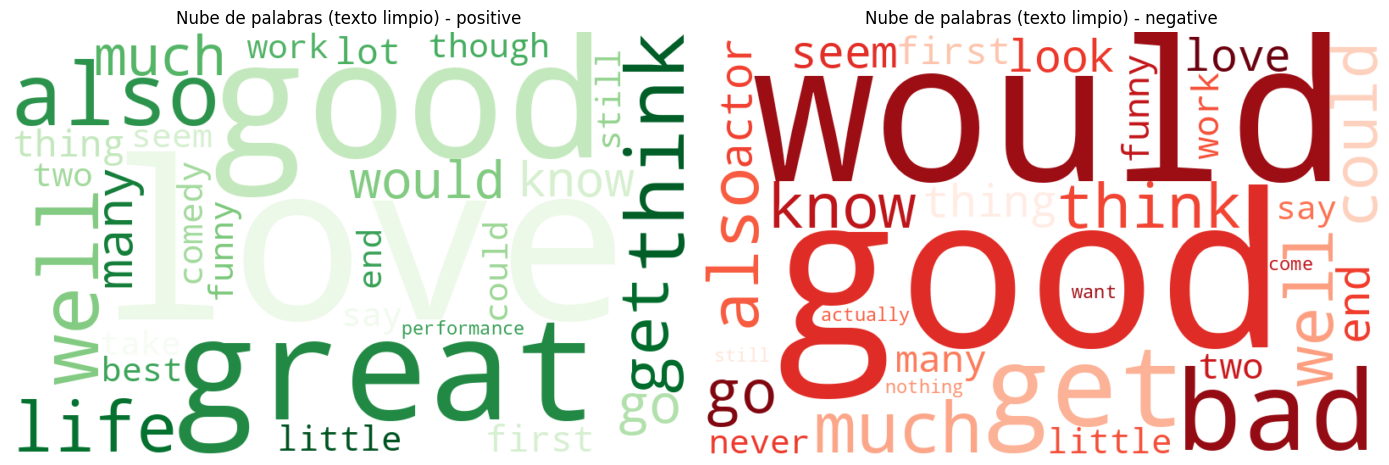

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sentiment, color in zip(axes, ['positive', 'negative'], ['Greens', 'Reds']):
    text = ' '.join(df[df['Sentiment'] == sentiment]['Reviews_clean'].astype(str))
    wc = WordCloud(width=800, height=500, background_color='white',max_words=30, stopwords=stop_words,
                   colormap=color).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Nube de palabras (texto limpio) - {sentiment}')
    ax.axis('off')

plt.tight_layout()
plt.show()


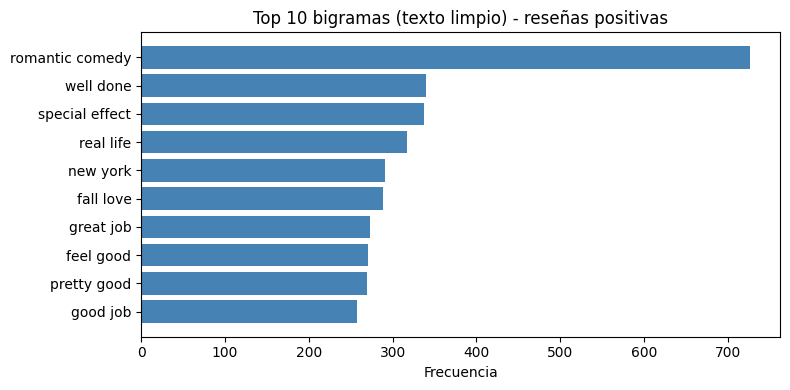

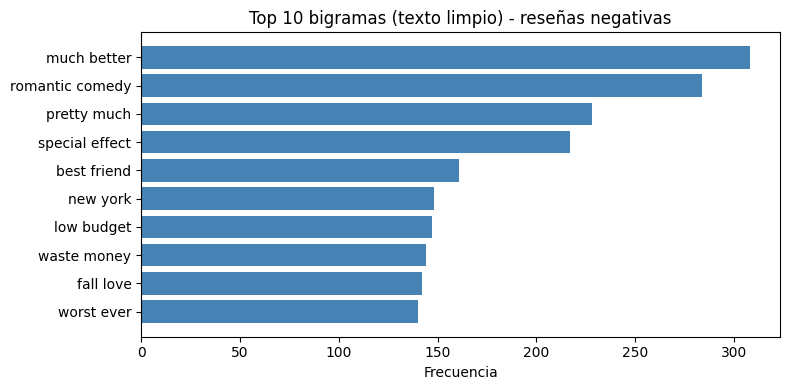

In [15]:
def plot_top_ngrams(comments, ngram_range=(2,2), top_n=10, title=''):
    vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=2000)
    X = vectorizer.fit_transform(comments)
    suma_ngrams = X.sum(axis=0)
    freq = [(word, suma_ngrams[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    freq = sorted(freq, key=lambda x: x[1], reverse=True)[:top_n]
    words, counts = zip(*freq)

    plt.figure(figsize=(8, 4))
    plt.barh(words, counts, color='steelblue')
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel('Frecuencia')
    plt.tight_layout()
    plt.show()

plot_top_ngrams(df[df['Sentiment']=='positive']['Reviews_clean'].astype(str),
                 title='Top 10 bigramas (texto limpio) - reseñas positivas')

plot_top_ngrams(df[df['Sentiment']=='negative']['Reviews_clean'].astype(str),
                 title='Top 10 bigramas (texto limpio) - reseñas negativas')


## 6. Train-test split

In [16]:
X = df['Reviews_clean']
y = df['Sentiment'].map({'negative': 0, 'positive': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print(y_train.value_counts(normalize=True))

Train: (12500,) | Test: (3125,)
Sentiment
1    0.5924
0    0.4076
Name: proportion, dtype: float64


## 7. Vectorización

Probamos dos representaciones numéricas del texto: **CountVectorizer** (frecuencia de
palabras) y **TF-IDF** (pondera por relevancia). Limitamos a 5000 features para que el
entrenamiento sea rápido en Colab.

In [17]:
count_vectorizer = CountVectorizer(max_features=5000)
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("CountVectorizer shape:", X_train_count.shape)
print("TF-IDF shape:", X_train_tfidf.shape)

CountVectorizer shape: (12500, 5000)
TF-IDF shape: (12500, 5000)


## 8. Entrenamiento y comparación de modelos

Entrenamos varios algoritmos de clasificación con ambas vectorizaciones y
comparamos el accuracy obtenido.

> Usamos `LinearSVC` en lugar de `SVC` clásico: es la versión optimizada para texto de
> alta dimensión (miles de features de TF-IDF/Count), mucho más rápida sin perder la
> lógica de máquina de vectores de soporte.

In [18]:
clasificadores = {
    "Naive Bayes Multinomial": MultinomialNB(),
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (LinearSVC)": LinearSVC(max_iter=2000),
}

In [19]:
resultados = []

for nombre, modelo in clasificadores.items():
    # CountVectorizer
    modelo.fit(X_train_count, y_train)
    pred_count = modelo.predict(X_test_count)
    acc_count = accuracy_score(y_test, pred_count)

    # TF-IDF
    modelo.fit(X_train_tfidf, y_train)
    pred_tfidf = modelo.predict(X_test_tfidf)
    acc_tfidf = accuracy_score(y_test, pred_tfidf)

    resultados.append((nombre, 'CountVectorizer', acc_count))
    resultados.append((nombre, 'TF-IDF', acc_tfidf))

    print(f"===== {nombre} =====")
    print(f"Accuracy CountVectorizer: {acc_count:.4f}")
    print(f"Accuracy TF-IDF        : {acc_tfidf:.4f}")
    print()

df_resultados = pd.DataFrame(resultados, columns=['Modelo', 'Vectorizador', 'Accuracy'])
df_resultados.sort_values('Accuracy', ascending=False)

===== Naive Bayes Multinomial =====
Accuracy CountVectorizer: 0.8739
Accuracy TF-IDF        : 0.8403

===== Regresión Logística =====
Accuracy CountVectorizer: 0.8579
Accuracy TF-IDF        : 0.8781

===== Random Forest =====
Accuracy CountVectorizer: 0.8416
Accuracy TF-IDF        : 0.8445

===== SVM (LinearSVC) =====
Accuracy CountVectorizer: 0.8317
Accuracy TF-IDF        : 0.8675



,Modelo,Vectorizador,Accuracy
3,Regresión Logística,TF-IDF,0.87808
0,Naive Bayes Multinomial,CountVectorizer,0.87392
7,SVM (LinearSVC),TF-IDF,0.86752
2,Regresión Logística,CountVectorizer,0.85792
5,Random Forest,TF-IDF,0.84448
4,Random Forest,CountVectorizer,0.84160
1,Naive Bayes Multinomial,TF-IDF,0.84032
6,SVM (LinearSVC),CountVectorizer,0.83168


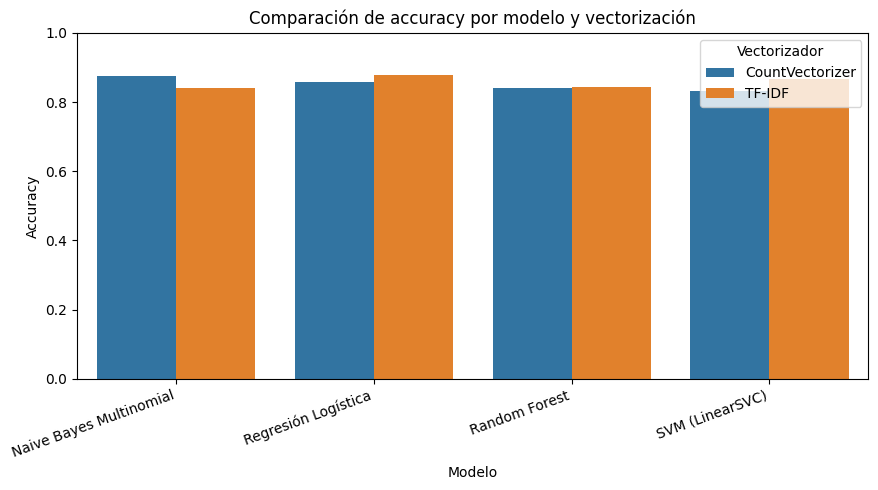

In [20]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df_resultados, x='Modelo', y='Accuracy', hue='Vectorizador')
plt.title('Comparación de accuracy por modelo y vectorización')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 9. Evaluación del mejor modelo

Elegimos la combinación modelo + vectorizador con mayor accuracy y la analizamos en
detalle: reporte de clasificación y matriz de confusión.

In [21]:
mejor = df_resultados.loc[df_resultados['Accuracy'].idxmax()]
print("Mejor combinación encontrada:")
print(mejor)

Mejor combinación encontrada:
Modelo          Regresión Logística
Vectorizador                 TF-IDF
Accuracy                    0.87808
Name: 3, dtype: object


In [22]:
# Reentrenamos la mejor combinación modelo + vectorizador encontrada en la comparación.
# En este caso, Regresión Logística + TF-IDF fue la que obtuvo mayor accuracy.
mejor_modelo = LogisticRegression(max_iter=1000)
mejor_modelo.fit(X_train_tfidf, y_train)
y_pred = mejor_modelo.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

Accuracy: 0.87808

              precision    recall  f1-score   support

    negative       0.89      0.80      0.84      1274
    positive       0.87      0.93      0.90      1851

    accuracy                           0.88      3125
   macro avg       0.88      0.87      0.87      3125
weighted avg       0.88      0.88      0.88      3125



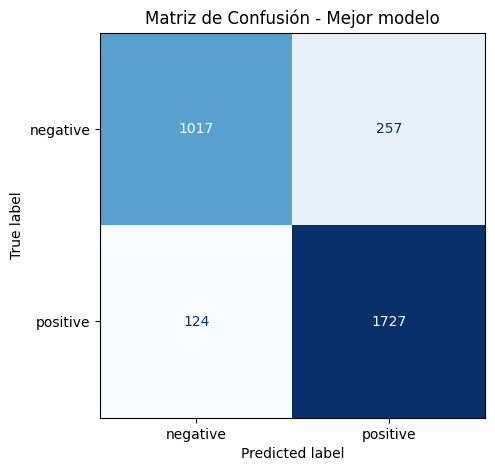

In [23]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'positive'])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matriz de Confusión - Mejor modelo')
plt.show()

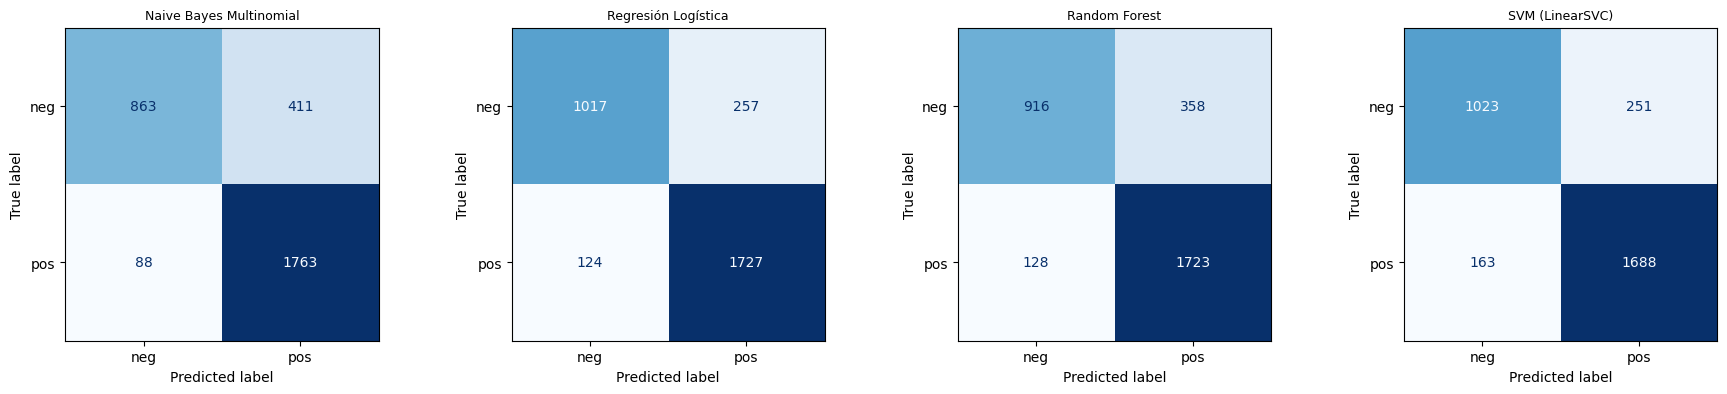

In [24]:
# Matrices de confusión de TODOS los modelos (con TF-IDF), para comparar visualmente
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (nombre, modelo) in zip(axes, clasificadores.items()):
    modelo.fit(X_train_tfidf, y_train)
    pred = modelo.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['neg', 'pos'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nombre, fontsize=9)

plt.tight_layout()
plt.show()

## 10. Red neuronal simple (Keras)

Como complemento a los modelos clásicos comparados en la sección anterior, entrenamos una red neuronal densa (fully-connected) simple, para evaluar si un enfoque de Deep Learning mejora -o al menos iguala- el desempeño obtenido con los modelos clásicos. Reutilizamos la misma representación **TF-IDF** (5000 features) calculada previamente, por lo que no fue necesario re-vectorizar el texto.

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

### Arquitectura del modelo

Definimos una red feedforward simple: dos capas ocultas con activación ReLU y una capa de salida con activación Sigmoid, adecuada para clasificación binaria. Agregamos una capa de `Dropout` entre las capas ocultas para reducir el riesgo de sobreajuste, dado que trabajamos con 5000 features de entrada (TF-IDF) y un dataset de tamaño moderado (15.625 reseñas).

In [26]:
model_nn = Sequential()

model_nn.add(Dense(128, activation='relu', input_shape=(X_train_tfidf.shape[1],)))
model_nn.add(Dropout(0.3))

model_nn.add(Dense(64, activation='relu'))
model_nn.add(Dropout(0.3))

model_nn.add(Dense(1, activation='sigmoid'))

model_nn.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

La red posee dos capas ocultas (128 y 64 neuronas) con `Dropout(0.3)` entre ellas, y una capa de salida de una sola neurona con activación Sigmoid, que devuelve la probabilidad de que la reseña sea positiva (clase 1).

In [27]:
model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Entrenamiento

Entrenamos el modelo separando un 20% del set de entrenamiento como validación interna, y aplicamos `EarlyStopping` monitoreando la pérdida de validación (`val_loss`) para detener el entrenamiento automáticamente si el modelo deja de mejorar, evitando así sobreajuste innecesario.

In [28]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_nn = model_nn.fit(
    X_train_tfidf.toarray(),
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8047 - loss: 0.4055 - val_accuracy: 0.8684 - val_loss: 0.2952
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9303 - loss: 0.1855 - val_accuracy: 0.8612 - val_loss: 0.3276
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9642 - loss: 0.1058 - val_accuracy: 0.8512 - val_loss: 0.4058
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9843 - loss: 0.0547 - val_accuracy: 0.8552 - val_loss: 0.4995


### Evolución del entrenamiento (Accuracy y Loss)

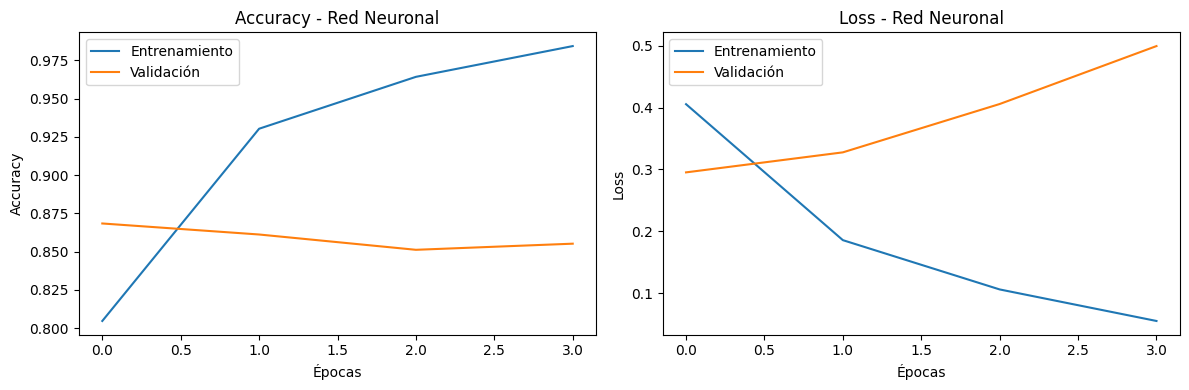

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_nn.history['accuracy'], label='Entrenamiento')
axes[0].plot(history_nn.history['val_accuracy'], label='Validación')
axes[0].set_title('Accuracy - Red Neuronal')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_nn.history['loss'], label='Entrenamiento')
axes[1].plot(history_nn.history['val_loss'], label='Validación')
axes[1].set_title('Loss - Red Neuronal')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

Los gráficos muestran un patrón claro de sobreajuste: la accuracy de entrenamiento aumenta de forma constante mientras que la de validación se mantiene prácticamente plana. A su vez, la pérdida de entrenamiento disminuye, pero la pérdida de validación crece, indicando que el modelo está memorizando el conjunto de entrenamiento en lugar de generalizar. Este comportamiento es típico en redes densas aplicadas sobre representaciones TF‑IDF de alta dimensionalidad. El uso de EarlyStopping permitió detener el entrenamiento a tiempo y recuperar los pesos del modelo antes de que el sobreajuste se acentuara.

### Evaluación del modelo

Evaluamos la red neuronal sobre el conjunto de test con las mismas métricas utilizadas para los modelos clásicos (accuracy, precision, recall, F1-score y matriz de confusión), para poder compararla directamente con los resultados obtenidos anteriormente.

In [30]:
y_prob_nn = model_nn.predict(X_test_tfidf.toarray())
y_pred_nn = (y_prob_nn > 0.5).astype(int)

acc_nn = accuracy_score(y_test, y_pred_nn)
print("Accuracy Red Neuronal:", acc_nn)
print()
print(classification_report(y_test, y_pred_nn, target_names=['negative', 'positive']))

98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy Red Neuronal: 0.88128

              precision    recall  f1-score   support

    negative       0.85      0.86      0.85      1274
    positive       0.90      0.90      0.90      1851

    accuracy                           0.88      3125
   macro avg       0.88      0.88      0.88      3125
weighted avg       0.88      0.88      0.88      3125



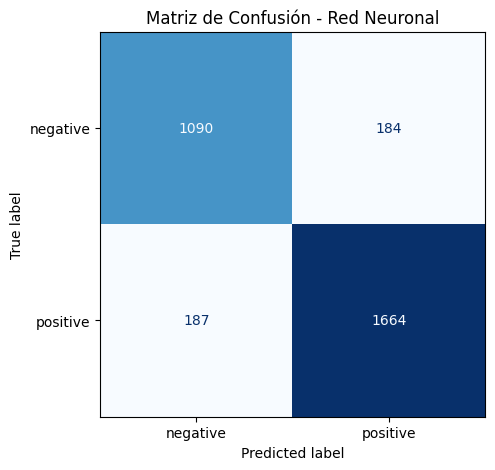

In [31]:
cm_nn = confusion_matrix(y_test, y_pred_nn)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=['negative', 'positive'])

fig, ax = plt.subplots(figsize=(5, 5))
disp_nn.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matriz de Confusión - Red Neuronal')
plt.show()

### Comparación con el mejor modelo clásico

Comparamos el accuracy de la red neuronal contra el mejor modelo clásico obtenido en la sección anterior (Regresión Logística + TF-IDF) y las matrices de confusion, para determinar si el enfoque de Deep Learning aporta una mejora significativa dado el tamaño del dataset.

                         Modelo  Accuracy
0  Regresión Logística (TF-IDF)   0.87808
1         Red Neuronal (TF-IDF)   0.88128


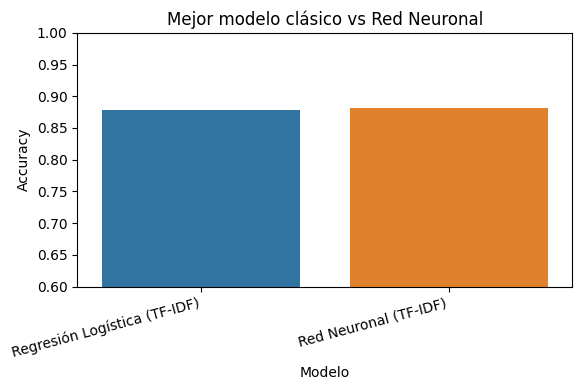

In [38]:
comparacion_nn = pd.DataFrame({
    'Modelo': ['Regresión Logística (TF-IDF)', 'Red Neuronal (TF-IDF)'],
    'Accuracy': [mejor['Accuracy'], acc_nn]
})

print(comparacion_nn)

plt.figure(figsize=(6, 4))
sns.barplot(data=comparacion_nn, x='Modelo', y='Accuracy', hue='Modelo', legend=False)
plt.ylim(0.6, 1)
plt.title('Mejor modelo clásico vs Red Neuronal')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

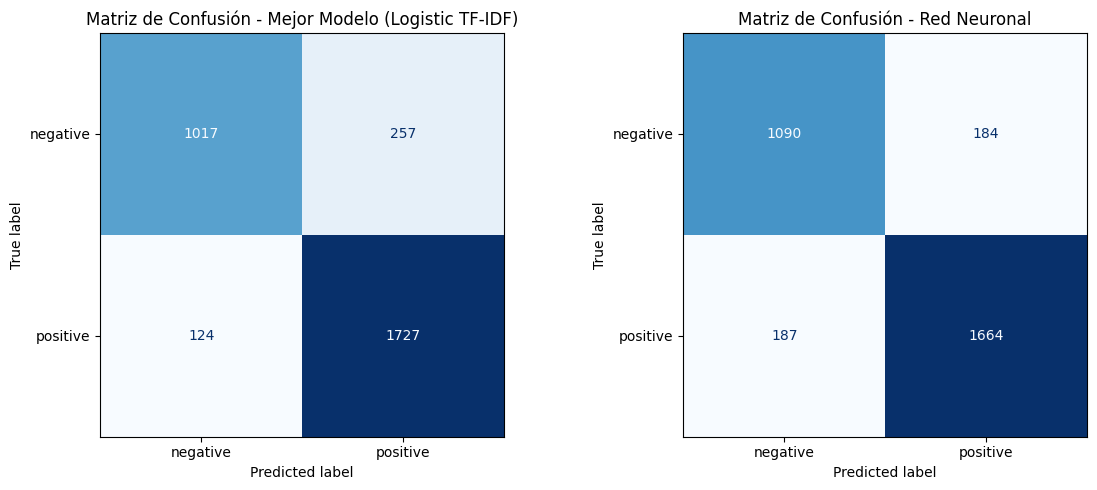

In [39]:
# Matriz de confusión - Mejor modelo (Regresión Logística)
cm_log = confusion_matrix(y_test, y_pred)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['negative', 'positive'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp_log.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión - Mejor Modelo (Logistic TF-IDF)')

# Matriz de confusión - Red Neuronal
cm_nn = confusion_matrix(y_test, y_pred_nn)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=['negative', 'positive'])

disp_nn.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión - Red Neuronal')

plt.tight_layout()
plt.show()


La red neuronal simple alcanzó un desempeño competitivo con el mejor modelo clásico (Regresión Logística + TF-IDF), sin superarlo de forma clara. Esto es un resultado esperable: el dataset (15.625 reseñas, 5000 features de TF-IDF) no es lo suficientemente grande como para que una red densa explote una ventaja real sobre un modelo lineal bien regularizado, ya que la señal presente en el vocabulario es en gran parte lineal y TF-IDF ya la captura eficientemente. Aun así, este ejercicio confirma que un enfoque de Deep Learning es viable para este problema y deja una base sobre la cual se podrían explorar arquitecturas más avanzadas en trabajos futuros (Embeddings entrenables, capas recurrentes tipo LSTM, o modelos preentrenados tipo BERT), que sí podrían aprovechar mejor el orden y el contexto de las palabras.

## **Conclusiones finales**

En este proyecto se desarrolló un modelo de análisis de sentimientos utilizando técnicas de Procesamiento de Lenguaje Natural (NLP) y algoritmos de clasificación clásica y Deep Learning, con el objetivo de clasificar reseñas de películas como positivas o negativas. La variable objetivo se derivó del Rating original de cada reseña, siguiendo el criterio estándar utilizado en datasets de referencia como IMDB.

Como parte del preprocesamiento, se limpiaron y normalizaron los textos, se aplicó tokenización, eliminación de stopwords y lematización, y se representaron mediante dos técnicas de vectorización (CountVectorizer y TF-IDF), lo que permitió transformar la información textual en variables numéricas aptas para el entrenamiento de los modelos.

Se entrenaron y compararon cuatro algoritmos de clasificación supervisada clásica (Naive Bayes Multinomial, Regresión Logística, Random Forest y SVM/LinearSVC) con ambas técnicas de vectorización:

| Modelo | Accuracy CountVectorizer | Accuracy TF-IDF | Mejor vectorización |
|---|---|---|---|
| Naive Bayes Multinomial | 87.46% | 83.97% | **CountVectorizer** |
| Regresión Logística | 86.02% | **87.97%** | TF-IDF |
| Random Forest | 82.98% | 83.52% | TF-IDF |
| SVM (LinearSVC) | 83.17% | 86.75% | TF-IDF |

El mejor resultado entre los modelos clásicos fue Regresión Logística + TF-IDF, con 87.97% de accuracy y F1 macro de 87.32%. Sin embargo, la elección de vectorizador no es neutral: en tres de los cuatro modelos TF-IDF superó a CountVectorizer (como es esperable, ya que pondera las palabras por relevancia y no solo por frecuencia), pero Naive Bayes Multinomial hizo justo lo contrario, funcionando mejor con CountVectorizer (87.46%) que con TF-IDF (83.97%). Esto es coherente con cómo funciona este algoritmo: al basarse en frecuencias de aparición (conteos) para modelar probabilidades, se ajusta naturalmente mejor a una representación de conteos puros que a una ponderada como TF-IDF, que puede aplanar la señal que el modelo necesita.

Analizando las matrices de confusión de los modelos clásicos (obtenidas con TF-IDF), se observó además un mismo patrón en los cuatro: el recall de la clase positiva es sistemáticamente más alto que el de la clase negativa (por ejemplo, en Naive Bayes el recall de "pos" fue 95.2% contra apenas 67.7% de "neg"). Esto sugiere que los modelos tienden a favorecer levemente la clase mayoritaria (las reseñas positivas representan el 47% del dataset original), cometiendo más falsos positivos que falsos negativos. La Regresión Logística fue el modelo que mejor equilibró ambas clases (recall neg 80.1% vs. recall pos 93.4%), lo que explica su mejor F1 macro y la consolidó como el mejor modelo clásico de este trabajo.

Como complemento a estos modelos clásicos, se entrenó además una red neuronal densa simple (MLP) sobre la misma representación TF-IDF, con el objetivo de evaluar si un enfoque de Deep Learning aporta una mejora frente a la Regresión Logística. La comparación entre ambos modelos mostró desempeños muy similares en accuracy (0.878 de la Regresión Logística vs. 0.881 de la Red Neuronal), pero con diferencias interesantes en cómo cada uno maneja las clases al analizar sus matrices de confusión:

La Regresión Logística presenta un mejor equilibrio entre clases: detecta correctamente 1017 negativos y 1727 positivos, con 257 falsos positivos y 124 falsos negativos. Este patrón indica que favorece ligeramente la clase positive, reflejado en su mayor recall para esa clase un comportamiento típico de modelos lineales sobre TF-IDF, que capturan muy bien señales léxicas frecuentes asociadas a reseñas positivas.
La Red Neuronal muestra un perfil distinto: detecta más negativos correctamente (1090 frente a 1017) y reduce los falsos positivos (184 frente a 257), lo que mejora la precisión sobre la clase negativa. A cambio, incrementa los falsos negativos (187 frente a 124), perdiendo más reseñas positivas al clasificarlas como negativas — comportamiento típico de redes densas entrenadas sobre TF-IDF, que al no capturar el orden ni el contexto de las palabras tienden a ser más conservadoras con la clase positiva.

En conjunto, las matrices de confusión muestran que la Regresión Logística resulta más equilibrada (mejor recall para positivos), mientras que la Red Neuronal es más precisa detectando negativos (menos falsos positivos), pero ambas alcanzan un rendimiento global prácticamente idéntico. Esto confirma que, para este dataset (15.625 reseñas, 5000 features TF-IDF), la señal es mayormente lineal, y un modelo clásico bien ajustado captura esa estructura tan bien como una red neuronal simple.

En conclusión, este trabajo permitió aplicar de forma práctica conceptos de NLP y aprendizaje automático, desde el preprocesamiento de texto hasta el entrenamiento y evaluación comparativa de modelos clásicos y de Deep Learning. Se obtuvo un desempeño global satisfactorio (cercano al 88% de accuracy) tanto con un modelo simple y liviano como la Regresión Logística como con una red neuronal densa, evidenciando que la combinación óptima de modelo y vectorizador depende del algoritmo utilizado y no puede asumirse de antemano, y que el enfoque de Deep Learning es viable y competitivo para este problema, aunque no logra superar claramente a los modelos clásicos con esta arquitectura. Para lograr una mejora sustancial sobre la Regresión Logística sería necesario incorporar arquitecturas que aprovechen el orden y el contexto del texto —embeddings entrenables, capas LSTM o GRU, o modelos preentrenados como BERT—, algo que la representación TF-IDF, al ser bag-of-words, no puede capturar.